# Analysis for Weather data

In [1]:
# for plot show
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

In [2]:
# load packages
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from numpy.ma.core import shape
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import IFrame

## check the shape, missing value, and data frequency

In [3]:
# loading data
def load_all_tables(db_path):
    conn = sqlite3.connect(db_path)
    # load daily data from CHMU
    daily = pd.read_sql("SELECT * FROM daily", conn)
    print("daily shape:", daily.shape)
    print(daily.head())
    print(daily.tail())
    # load hourly data from CHMU
    hourly = pd.read_sql("SELECT * FROM hourly", conn)
    print("hourly shape:", hourly.shape)
    print(hourly.head())
    print(hourly.tail())
    # load minute data from CHMU
    minute = pd.read_sql("SELECT * FROM minute", conn)
    print("minute shape:", minute.shape)
    print(minute.head())
    print(minute.tail())
    # load owm_weather
    owm_weather = pd.read_sql("SELECT * FROM owm_weather", conn)
    print("owm_weather shape:", owm_weather.shape)
    print(owm_weather.head())
    print(owm_weather.tail())
    # load owm_pollution
    owm_pollution = pd.read_sql("SELECT * FROM owm_pollution", conn)
    print("owm_pollution shape:", owm_pollution.shape)
    print(owm_pollution.head())
    print(owm_pollution.tail())
    # load open_meteo_hourly
    open_meteo_hourly = pd.read_sql("SELECT * FROM open_meteo_hourly", conn)
    print("open_meteo_hourly shape:", open_meteo_hourly.shape)
    print(open_meteo_hourly.head())
    print(open_meteo_hourly.tail())
    # load open_meteo_daily
    open_meteo_daily = pd.read_sql("SELECT * FROM open_meteo_daily", conn)
    print("open_meteo_daily shape:", open_meteo_daily.shape)
    print(open_meteo_daily.head())
    print(open_meteo_daily.tail())
    # load synoptic table
    synoptic = pd.read_sql("SELECT * FROM synoptic", conn)
    print("synoptic shape:", synoptic.shape)
    print(synoptic.head())
    print(synoptic.tail())

    conn.close()
    return daily, hourly, minute, owm_weather, owm_pollution, open_meteo_hourly, open_meteo_daily, synoptic

# call the function
daily, hourly, minute, owm_weather, owm_pollution, open_meteo_hourly, open_meteo_daily, synoptic = load_all_tables("/Users/user/PyCharmMiscProject/weather.db")

daily shape: (216072, 42)
         date sunshine_duration wind_dir_at_gust vapour_pressure_avg  \
0  2026-04-30            1715.0              7.0                 4.4   
1  2026-04-30            1658.0              2.0                 4.8   
2  2026-04-30            1753.0            321.0                 4.7   
3  2026-04-30               NaN              NaN                 NaN   
4  2026-04-30               NaN              NaN                 4.7   

  wind_speed_avg wind_gust_max humidity_avg pressure_avg sunshine_hours  \
0            1.8           8.3         37.0       1000.3           13.9   
1            1.5           7.6         42.0        996.6           14.2   
2            1.4           7.5         37.0       1007.2           12.4   
3            NaN           NaN          NaN          NaN            NaN   
4            NaN           NaN         46.0          NaN            NaN   

  temp_avg  ... soil_temp_100cm_06AM soil_temp_10cm_06AM soil_temp_20cm_06AM  \
0     10.7

In [4]:
# checking for missing value and data range
tables = {
    'daily': (daily, 'date'),
    'hourly': (hourly, 'date'),
    'minute': (minute, 'date'),
    'open_meteo_hourly': (open_meteo_hourly, 'timestamp'),
    'open_meteo_daily': (open_meteo_daily, 'date'),
    'owm_weather': (owm_weather, 'timestamp'),
    'owm_pollution': (owm_pollution, 'timestamp'),
    'synoptic': (synoptic, 'date'),
}

for name, (df, date_col) in tables.items():
    print(f"\n{'='*40}")
    print(f"TABLE: {name}")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df[date_col].min()} → {df[date_col].max()}")
    print(f"\nMissing values in %:")
    print(df.isnull().sum() / len(df) * 100)


TABLE: daily
Shape: (216072, 42)
Date range: 1775-01-01 → 2026-06-02

Missing values in %:
date                        0.000000
sunshine_duration          55.611555
wind_dir_at_gust           55.499093
vapour_pressure_avg        31.531156
wind_speed_avg              0.278611
wind_gust_max              55.456977
humidity_avg               11.926580
pressure_avg                0.333222
sunshine_hours             31.705635
temp_avg                    0.134215
precip_index_30d            5.097838
snow_water_equiv           22.364304
snow_water_equiv_change    22.364304
new_snow_depth             29.125940
precipitation               6.506165
total_snow_depth           63.411733
temp_overnight_min         70.302492
temp_ground_surface        53.915824
temp_max                    0.202710
temp_min                    0.202710
year                        0.000000
month                       0.000000
weekday_name                0.000000
is_weekend                  0.000000
station             

In [5]:
# convert date column in open_meteo to proper datetime
open_meteo_daily['date'] = pd.to_datetime(open_meteo_daily['date'])

## Temperature Analysis

### basic visual analysis with temperature

- mapping the temperature by colors
- plotting historical temp in histogram, better sees the allocation
- average temperature by 10 years gap, for historical data
- box plot for the hourly data, picking each day in every 20 years or so
- correlation matrix for temperature with some other relevant elements (e.g., soil_temp, solar_radiation, ...)
- tbc

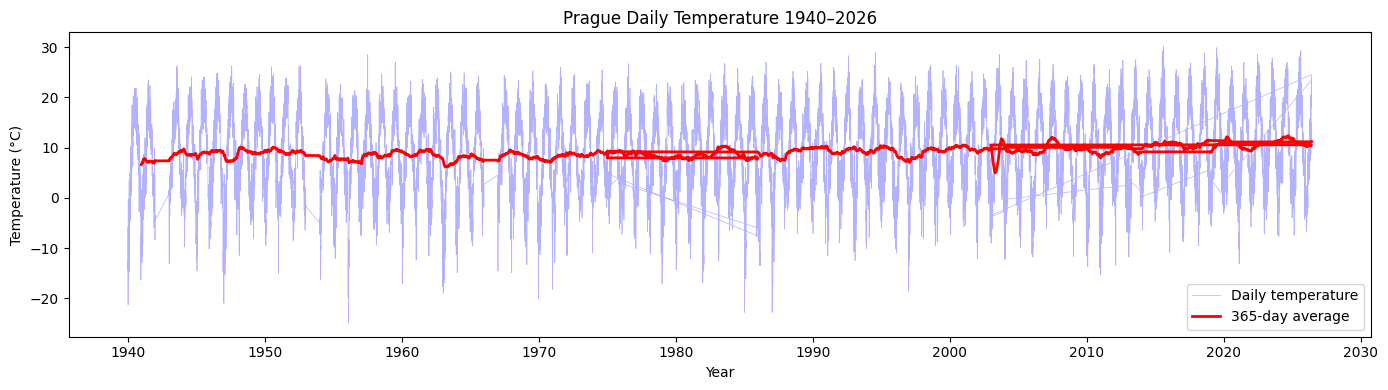

In [6]:
# plot raw temperature
plt.style.use('default')
plt.figure(figsize=(14, 4))
plt.plot(open_meteo_daily['date'], open_meteo_daily['temperature_mean'],
         color='blue', alpha=0.3, linewidth=0.5, label='Daily temperature')
plt.plot(open_meteo_daily['date'], open_meteo_daily['temperature_mean'].rolling(365).mean(),
         color='red', linewidth=2, label='365-day average')
plt.title('Prague Daily Temperature 1940–2026')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

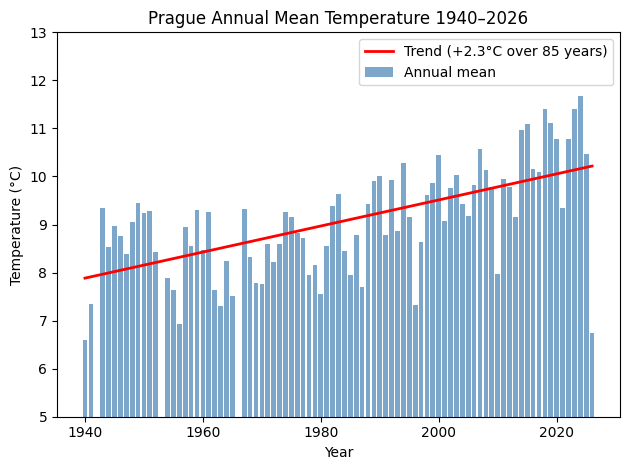

In [7]:
# grouping by annual
annual = open_meteo_daily.groupby(open_meteo_daily['date'].dt.year)['temperature_mean'].mean()

# plot
plt.style.use('default')
plt.bar(annual.index, annual.values, color='steelblue', alpha=0.7, label='Annual mean')
plt.ylim(5, 13)
# add trends to the data
z = np.polyfit(annual.index, annual.values, 1)
p = np.poly1d(z)
plt.plot(annual.index, p(annual.index), color='red', linewidth=2, label=f'Trend (+{z[0]*85:.1f}°C over 85 years)')
plt.title('Prague Annual Mean Temperature 1940–2026')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# monthly average by decade
# checking monthly shape
open_meteo_daily['decade'] = (open_meteo_daily['date'].dt.year // 10) * 10
monthly = open_meteo_daily.groupby(['decade', open_meteo_daily['date'].dt.month])['temperature_mean'].mean().unstack()

monthly.shape

(9, 12)

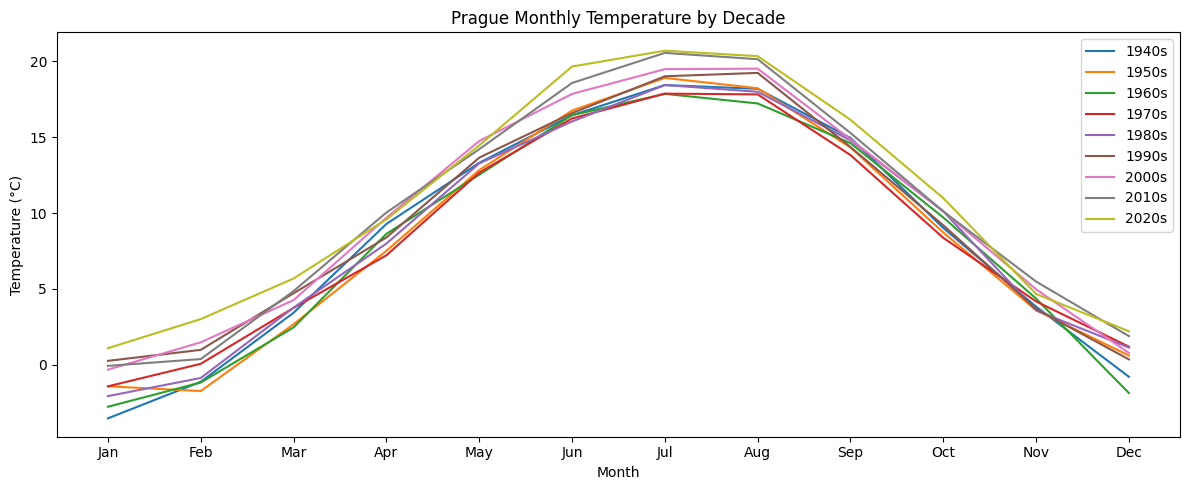

In [9]:
# monthly: 9 decades with 12 months
plt.style.use('default')
plt.figure(figsize=(12, 5))

for decade in monthly.index:
    plt.plot(monthly.columns, monthly.loc[decade], label=str(decade)+'s')

plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Prague Monthly Temperature by Decade')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# average out the figure across different station
daily['temp_avg'] = pd.to_numeric(daily['temp_avg'], errors='coerce')
daily['date'] = pd.to_datetime(daily['date'])

In [11]:
daily_avg = daily.groupby('date')['temp_avg'].mean().reset_index()

In [12]:
print(daily_avg.shape)
print(daily_avg.head())

(91824, 2)
        date  temp_avg
0 1775-01-01      -7.0
1 1775-01-02      -2.2
2 1775-01-03      -1.0
3 1775-01-04       0.1
4 1775-01-05       2.2


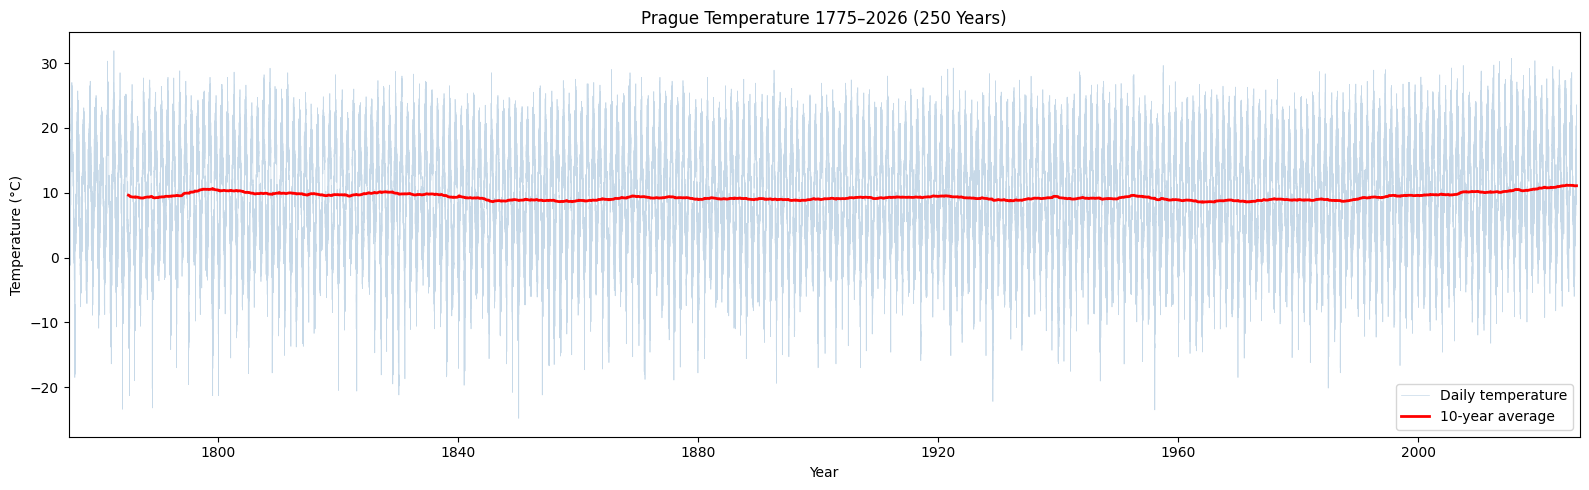

In [13]:
plt.style.use('default')
plt.figure(figsize=(16, 5))

# raw daily temperature
plt.plot(daily_avg['date'], daily_avg['temp_avg'],
         color='steelblue', alpha=0.3, linewidth=0.5, label='Daily temperature')

# rolling average
plt.plot(daily_avg['date'], daily_avg['temp_avg'].rolling(3650).mean(),
         color='red', linewidth=2, label='10-year average')

plt.title('Prague Temperature 1775–2026 (250 Years)')
# prevent cutting
plt.xlim(pd.Timestamp('1775-01-01'), pd.Timestamp('2026-12-31'))
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

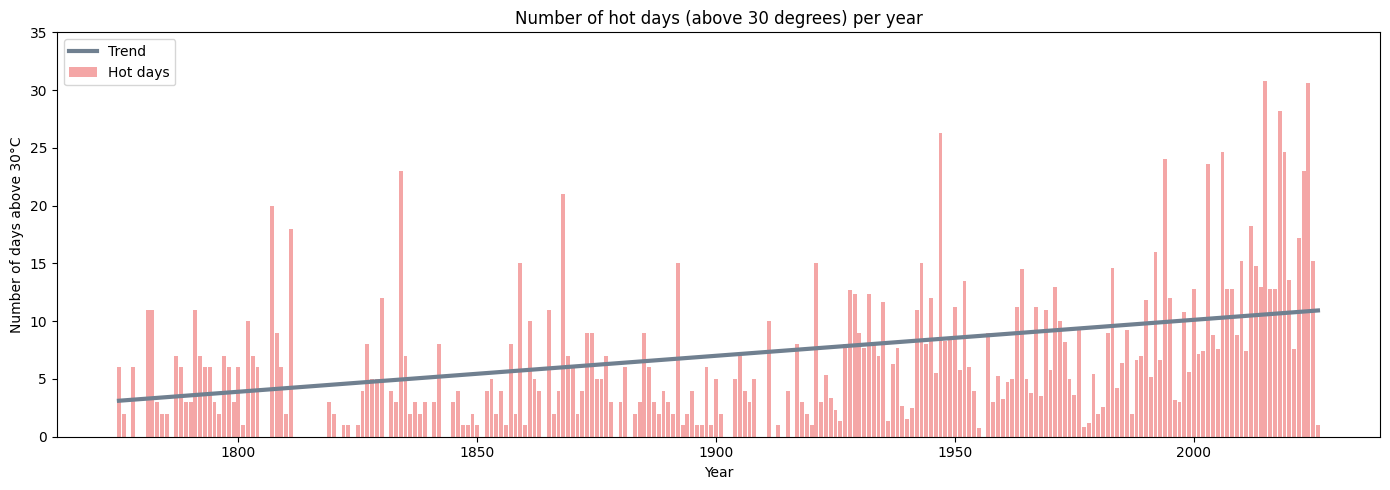

In [14]:
# plot for CHMU count the temperature that are more than 30 degrees
plt.style.use('default')

# filter with specification
daily['temp_max'] = pd.to_numeric(daily['temp_max'], errors='coerce')
hot_days = daily[daily['temp_max'] > 30]
# group by the year, and count
hot_per_year = hot_days.groupby(hot_days['date'].dt.year)['temp_max'].count()
# fixed trend line with calculation
hot_per_year = hot_days.groupby(hot_days['date'].dt.year)['temp_max'].count() / daily.groupby(daily['date'].dt.year)['station'].nunique()
hot_per_year = hot_per_year.dropna()

# plot
plt.figure(figsize=(14, 5))
plt.bar(hot_per_year.index, hot_per_year.values, color='lightcoral', alpha=0.7, label='Hot days')

# trend line
# convert int
x = hot_per_year.index.astype(int).values
y = hot_per_year.values

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), color='slategrey', linewidth=3, label='Trend', zorder=5)

plt.title('Number of hot days (above 30 degrees) per year')
# fixed trend line
plt.ylim(0, 35)
plt.xlabel('Year')
plt.ylabel('Number of days above 30°C')
plt.legend()
plt.tight_layout()
plt.show()

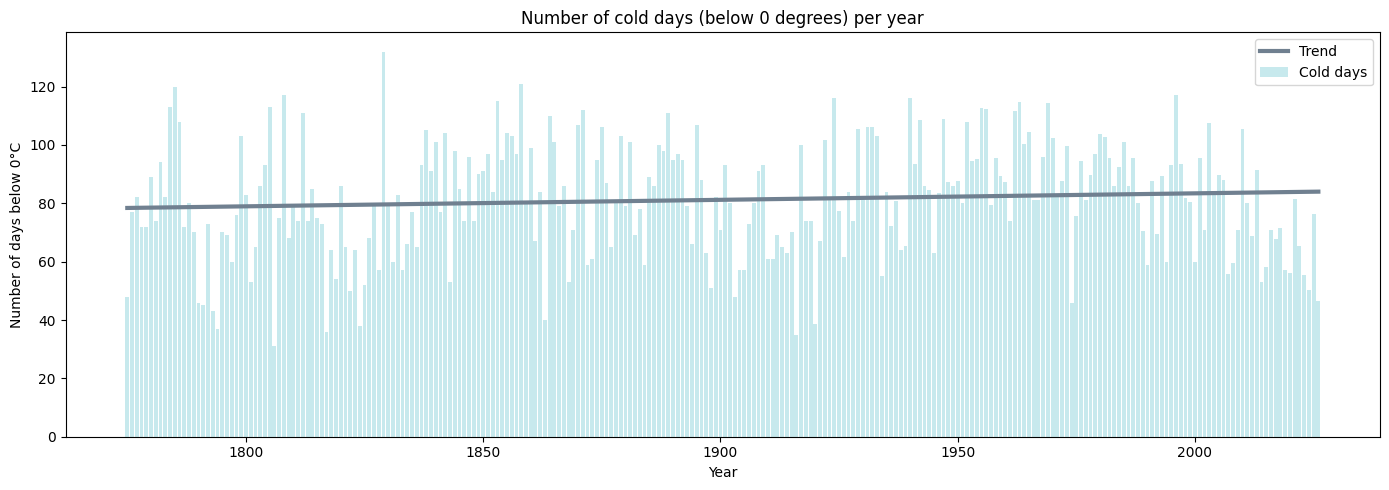

In [15]:
# plot for CHMU count the temperature that are less than 0 degrees
plt.style.use('default')

# filter with specification
daily['temp_min'] = pd.to_numeric(daily['temp_min'], errors='coerce')
cold_days = daily[daily['temp_min'] < 0]
# group by the year, and count
cold_per_year = cold_days.groupby(hot_days['date'].dt.year)['temp_min'].count()
# fixed trend line with calculation
cold_per_year = cold_days.groupby(cold_days['date'].dt.year)['temp_min'].count() / daily.groupby(daily['date'].dt.year)['station'].nunique()
cold_per_year = cold_per_year.dropna()

# plot
plt.figure(figsize=(14, 5))
plt.bar(cold_per_year.index, cold_per_year.values, color='powderblue', alpha=0.7, label='Cold days')

# trend line
# convert int
x = cold_per_year.index.astype(int).values
y = cold_per_year.values

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), color='slategrey', linewidth=3, label='Trend', zorder=5)

plt.title('Number of cold days (below 0 degrees) per year')
# fixed trend line
plt.xlabel('Year')
plt.ylabel('Number of days below 0°C')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# plot for temperature distribution boxplot
plt.style.use('default')

# filter
s1700 = daily_avg[daily_avg['date'].dt.year < 1800]['temp_avg']
s1800 = daily_avg[(daily_avg['date'].dt.year >= 1800) & (daily_avg['date'].dt.year < 1900)]['temp_avg']
s1900 = daily_avg[(daily_avg['date'].dt.year >= 1900) & (daily_avg['date'].dt.year < 1950)]['temp_avg']
s1950 = daily_avg[(daily_avg['date'].dt.year >= 1950) & (daily_avg['date'].dt.year < 2000)]['temp_avg']
s2000 = daily_avg[(daily_avg['date'].dt.year >= 2000) & (daily_avg['date'].dt.year < 2020)]['temp_avg']
s2020 = daily_avg[daily_avg['date'].dt.year >= 2020]['temp_avg']

# combine all periods into one DataFrame
box_data = pd.DataFrame({
    'temperature': pd.concat([s1700, s1800, s1900, s1950, s2000, s2020]).values,
    'period': (['1775-1800'] * len(s1700) + ['1800-1900'] * len(s1800) +
               ['1900-1950'] * len(s1900) + ['1950-2000'] * len(s1950) +
               ['2000-2020'] * len(s2000) + ['2020+'] * len(s2020))
})

fig = px.box(box_data, x='period', y='temperature',
             color='period',
             color_discrete_sequence=px.colors.sequential.Plasma,
             title='Temperature Distribution Across Periods')

fig.update_layout(xaxis_title='Period', yaxis_title='Temperature (°C)')

fig.show()

fig.write_image("plots/Temperature_Distribution_Across_Periods.png")

![Temperature Distribution](plots/Temperature_Distribution_Across_Periods.png)

In [17]:
# plot cross-validation
# matching the timestamps
owm_weather['timestamp'] = pd.to_datetime(owm_weather['timestamp'])
open_meteo_hourly['timestamp'] = pd.to_datetime(open_meteo_hourly['timestamp'])

# filter open_meteo to same period as OWM
om_recent = open_meteo_hourly[open_meteo_hourly['timestamp'] >= '2026-05-13']

print(owm_weather.shape)
print(om_recent.shape)
print(owm_weather['timestamp'].min(), owm_weather['timestamp'].max())
print(om_recent['timestamp'].min(), om_recent['timestamp'].max())

(151, 9)
(386, 11)
2026-05-13 22:51:59 2026-06-04 18:06:17
2026-05-13 00:00:00 2026-06-04 18:00:00


In [18]:
# merged on the nearest timeline
merged = pd.merge_asof(
    owm_weather.sort_values('timestamp'),
    om_recent[['timestamp', 'temperature']].sort_values('timestamp'),
    on='timestamp',
    tolerance=pd.Timedelta('1hour'),
    suffixes=('_owm', '_om')
)

print(merged.shape)
print(merged[['timestamp', 'temperature_owm', 'temperature_om']].head())

(151, 10)
            timestamp  temperature_owm  temperature_om
0 2026-05-13 22:51:59             9.08             9.4
1 2026-05-13 22:54:16             9.01             9.4
2 2026-05-13 23:00:48             9.03            10.0
3 2026-05-14 00:03:54             8.60             8.6
4 2026-05-14 04:47:13             8.39             7.7


In [19]:
# plot the interactive graph
fig = px.scatter(merged,
                 x='temperature_owm',
                 y='temperature_om',
                 title='Cross-validation: OWM vs Open-Meteo Temperature',
                 labels={'temperature_owm': 'OWM Temperature (°C)',
                         'temperature_om': 'Open-Meteo Temperature (°C)'},
                 trendline='ols')

fig.show()

## Air Quality Analysis

### Basic Visual

- correlation matrix for temp with pollution
- extreme events happening frequency in each years
- plot to see if there's seasonal pattern
- tbc

In [20]:
fig = px.scatter(owm_pollution, x='timestamp', y='aqi',
                 color='aqi',
                 color_continuous_scale='RdYlGn_r',
                 size='pm2_5',
                 title='Air Quality Index - Prague May-June 2026',
                 labels={'aqi': 'AQI', 'timestamp': 'Date', 'pm2_5': 'PM2.5'})

fig.update_layout(yaxis_title='AQI')
fig.show()

In [21]:
# the time of the day has worst quality
owm_pollution['timestamp'] = pd.to_datetime(owm_pollution['timestamp'])
owm_pollution['hour'] = owm_pollution['timestamp'].dt.hour

hourly_aqi = owm_pollution.groupby('hour')['aqi'].mean().reset_index()

print(hourly_aqi.head())
print(hourly_aqi.columns.tolist())

   hour  aqi
0     0  1.1
1     3  1.0
2     4  1.4
3     5  1.0
4     6  2.0
['hour', 'aqi']


In [22]:
# bar chart
fig = px.bar(hourly_aqi, x='hour', y='aqi',
                color='aqi',
                color_continuous_scale='Sunset',
                title='Average AQI by Hour of Day - Prague May-June 2026',
                labels={'aqi': 'AQI', 'timestamp': 'Date', 'pm2_5': 'PM2.5'},
                category_orders={'hour': list(range(24))})

fig.update_layout(
    title='Average AQI by Hour of Day - Prague May-June 2026',
    bargap=0.1
)
fig.show()

In [23]:
# air pollutant
pollutants = owm_pollution[['no2', 'o3', 'so2', 'pm2_5', 'pm10']].mean().reset_index()
pollutants.columns = ['pollutant', 'avg_value']
print(pollutants)

  pollutant  avg_value
0       no2   2.266556
1        o3  66.245033
2       so2   0.506026
3     pm2_5   2.245828
4      pm10   3.103576


In [24]:
fig = px.pie(pollutants, values='avg_value', names='pollutant',
             title='Pollutant Composition - Prague May-June 2026')

fig.update_layout(
    barmode='stack',
    title='Pollutant Composition - Prague May-June 2026',
    yaxis_title='Average Concentration (μg/m³)'
)
fig.show()

In [25]:
# O3 dominates
pollutants_no_o3 = pollutants[pollutants['pollutant'] != 'o3']
print(pollutants_no_o3)

  pollutant  avg_value
0       no2   2.266556
2       so2   0.506026
3     pm2_5   2.245828
4      pm10   3.103576


In [26]:
# pollutant breakdown - barchart
# remove O3, cause it dominates
fig = px.bar(pollutants_no_o3, x='pollutant', y='avg_value',
             color='avg_value',
             color_continuous_scale='brwnyl',
             title='Pollutant Breakdown',
             labels={'pollutant': 'Pollutant', 'avg_value': 'Average Concentration (μg/m³)'})
fig.show()

## Soil and Solar Analysis

In [27]:
open_meteo_hourly['timestamp'] = pd.to_datetime(open_meteo_hourly['timestamp'])
open_meteo_hourly['hour'] = open_meteo_hourly['timestamp'].dt.hour
open_meteo_hourly['month'] = open_meteo_hourly['timestamp'].dt.month

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

open_meteo_hourly['season'] = open_meteo_hourly['month'].apply(get_season)

print(open_meteo_hourly[['timestamp', 'hour', 'month', 'season']].head())

            timestamp  hour  month  season
0 1940-01-01 00:00:00     0      1  Winter
1 1940-01-01 01:00:00     1      1  Winter
2 1940-01-01 02:00:00     2      1  Winter
3 1940-01-01 03:00:00     3      1  Winter
4 1940-01-01 04:00:00     4      1  Winter


In [28]:
# group by season and hour
solar = open_meteo_hourly.groupby(['season', 'hour'])['shortwave_radiation'].mean().reset_index()
print(solar.head())

   season  hour  shortwave_radiation
0  Autumn     0                  0.0
1  Autumn     1                  0.0
2  Autumn     2                  0.0
3  Autumn     3                  0.0
4  Autumn     4                  0.0


In [29]:
# plot solar radiation by season using open_meteo_hourly data
fig = px.line(solar, x='hour', y='shortwave_radiation',
              color='season',
              title='Solar Radiation Sorted by Season',
              labels={'shortwave_radiation': 'radiation scale', 'hour': 'time of the day'},
              color_discrete_map={
                  'Winter': 'blue',
                  'Spring': 'green',
                  'Summer': 'orange',
                  'Autumn': 'brown'
              })
fig.show()

In [30]:
# prep for plot soil temperature vs air temperature
soil_temp = open_meteo_hourly.groupby('month').agg(
    air_temp=('temperature', 'mean'),
    soil_0_7=('soil_temperature_0_to_7cm', 'mean'),
    soil_7_28=('soil_temperature_7_to_28cm', 'mean'),
    soil_28_100=('soil_temperature_28_to_100cm', 'mean')
).reset_index()

print(soil_temp)

    month   air_temp   soil_0_7  soil_7_28  soil_28_100
0       1  -1.333619   0.079995   0.608299     2.431558
1       2   0.020142   0.758277   0.876624     1.792750
2       3   3.886230   3.786556   3.391216     2.815672
3       4   8.686395   8.905926   8.230696     6.360900
4       5  13.491096  13.831733  13.005992    10.549809
5       6  17.055388  17.437859  16.612420    14.042918
6       7  18.929450  19.410446  18.737527    16.555209
7       8  18.650131  19.291612  18.992865    17.781352
8       9  14.743794  15.381074  15.626366    16.113320
9      10   9.595633  10.143448  10.790721    12.607833
10     11   4.205078   4.649233   5.493461     8.164512
11     12   0.586997   1.304804   2.048389     4.416704


In [31]:
# plot
# didn't merge with CHMU soil data, because of high missing value
fig = px.line(soil_temp, x='month', y=['air_temp', 'soil_0_7', 'soil_7_28', 'soil_28_100'],
              title='Air vs Soil Temperature by Month - Prague',
              labels={'value': 'Temperature (°C)', 'month': 'Month', 'variable': 'Layer'},
              color_discrete_map={
                  'air_temp': 'red',
                  'soil_0_7': 'orange',
                  'soil_7_28': 'brown',
                  'soil_28_100': 'darkgreen'
              })

# rename the label
fig.for_each_trace(lambda t: t.update(name={
    'air_temp': 'Air Temperature',
    'soil_0_7': 'Soil Depth 0-7cm',
    'soil_7_28': 'Soil Depth 7-28cm',
    'soil_28_100': 'Soil Depth 28-100cm'
}.get(t.name, t.name)))

fig.update_xaxes(tickvals=list(range(1,13)),
                 ticktext=['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
fig.show()

In [32]:
# plot for soil moisture seasonal pattern
# prep
soil_moisture = open_meteo_daily.groupby(open_meteo_daily['date'].dt.month).agg(
    moisture_0_7=('soil_moisture_0_7cm', 'mean'),
    moisture_0_100=('soil_moisture_0_100cm', 'mean'),
    moisture_28_100=('soil_moisture_28_100cm', 'mean')
).reset_index()

soil_moisture.head

<bound method NDFrame.head of     date  moisture_0_7  moisture_0_100  moisture_28_100
0      1      0.357018        0.329175         0.320360
1      2      0.364657        0.343576         0.336777
2      3      0.360359        0.350058         0.346302
3      4      0.328839        0.332388         0.334095
4      5      0.309858        0.305341         0.305935
5      6      0.297799        0.284144         0.283164
6      7      0.289813        0.267344         0.263115
7      8      0.284097        0.256438         0.250859
8      9      0.291017        0.256764         0.247691
9     10      0.306115        0.267590         0.256644
10    11      0.339615        0.290407         0.275194
11    12      0.352962        0.313607         0.300509>

In [33]:
# plot
fig = px.line(soil_moisture, x='date', y=['moisture_0_7', 'moisture_0_100', 'moisture_28_100'],
              title='Soil Moisture Seasonal Pattern',
              labels={'value': 'Soil Moisture (m³/m³)', 'date': 'Month', 'variable': 'Layer'})
# rename
fig.for_each_trace(lambda t: t.update(name={
    'moisture_0_7': 'Moisture 0-7cm',
    'moisture_0_100': 'Moisture 7-28cm',
    'moisture_28_100': 'Moisture 28-100cm'
}.get(t.name, t.name)))

fig.update_xaxes(tickvals=list(range(1,13)),
                 ticktext=['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
fig.show()

## Correlation HeatMap

In [34]:
corr_cols = ['temperature', 'humidity', 'wind_speed',
             'shortwave_radiation', 'cloud_cover',
             'soil_temperature_0_to_7cm',
             'soil_temperature_7_to_28cm',
             'soil_temperature_28_to_100cm',
             'precipitation']

corr_matrix = open_meteo_hourly[corr_cols].corr()
print(corr_matrix.round(2))

                              temperature  humidity  wind_speed  \
temperature                          1.00     -0.47       -0.04   
humidity                            -0.47      1.00       -0.17   
wind_speed                          -0.04     -0.17        1.00   
shortwave_radiation                  0.50     -0.65        0.04   
cloud_cover                         -0.13      0.22        0.18   
soil_temperature_0_to_7cm            0.97     -0.46       -0.10   
soil_temperature_7_to_28cm           0.90     -0.31       -0.15   
soil_temperature_28_to_100cm         0.80     -0.25       -0.15   
precipitation                        0.06      0.16        0.12   

                              shortwave_radiation  cloud_cover  \
temperature                                  0.50        -0.13   
humidity                                    -0.65         0.22   
wind_speed                                   0.04         0.18   
shortwave_radiation                          1.00        -0.15   

In [35]:
# plot the heatmap
fig = px.imshow(corr_matrix,
                color_continuous_scale='RdBu_r',
                zmin=-1, zmax=1,
                title='Correlation Heatmap - Weather Variables Prague',
                text_auto='.2f')

fig.update_layout(
    width=800,
    height=700,
    xaxis_tickangle=-45
)

fig.show()

In [36]:
# monthly correlation
daily['precipitation'] = pd.to_numeric(daily['precipitation'], errors='coerce')

precip_temp = daily.groupby(daily['date'].dt.month).agg(
    temp=('temp_avg', 'mean'),
    precip=('precipitation', 'mean')
).reset_index()

print(precip_temp)

    date       temp    precip
0      1  -0.698679  0.720986
1      2   0.624230  0.719648
2      3   4.339057  0.846728
3      4   9.276224  1.079538
4      5  14.318468  1.886955
5      6  17.701821  2.282566
6      7  19.436512  2.198499
7      8  18.859211  2.113939
8      9  14.813186  1.344017
9     10   9.493203  1.037106
10    11   4.276569  0.968929
11    12   0.807044  0.823295


In [37]:
# plot
fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Bar(x=precip_temp['date'], y=precip_temp['precip'],
           name='Precipitation (mm)', marker_color='steelblue', opacity=0.7),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=precip_temp['date'], y=precip_temp['temp'],
               name='Temperature (°C)', line=dict(color='red', width=3)),
    secondary_y=True
)

fig.update_layout(
    title='Monthly Temperature vs Precipitation - Prague (1775-2026)',
    xaxis=dict(tickvals=list(range(1,13)),
               ticktext=['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
)
fig.update_yaxes(title_text='Precipitation (mm)', secondary_y=False)
fig.update_yaxes(title_text='Temperature (°C)', secondary_y=True)
fig.show()

## Work with Data that Mainly from ČHMÚ

In [38]:
# prep for sunshine hours trend
daily['sunshine_hours'] = pd.to_numeric(daily['sunshine_hours'], errors='coerce')

sunshine_annual = daily.groupby(daily['date'].dt.year)['sunshine_hours'].mean().dropna()

fig = px.scatter(x=sunshine_annual.index, y=sunshine_annual.values,
                 trendline='ols',
                 title='Annual Average Sunshine Hours - Prague (ČHMÚ)',
                 labels={'x': 'Year', 'y': 'Sunshine Hours'},
                 color_discrete_sequence=['lightcoral'])
fig.show()

## Work with Synoptic Data

In [39]:
# shows humidity
synoptic['date'] = pd.to_datetime(synoptic['date'])
synoptic['vapour_pressure'] = pd.to_numeric(synoptic['vapour_pressure'], errors='coerce')
synoptic['month'] = synoptic['date'].dt.month

vapour_monthly = synoptic.groupby('month')['vapour_pressure'].mean().reset_index()
print(vapour_monthly)

    month  vapour_pressure
0       1         5.063858
1       2         5.233752
2       3         6.083097
3       4         7.475351
4       5        10.391918
5       6        13.004835
6       7        14.239320
7       8        14.180560
8       9        11.992865
9      10         9.358213
10     11         7.071759
11     12         5.639909


In [40]:
# plot
fig = px.line(vapour_monthly, x='month', y='vapour_pressure',
              title='Humidity Throughout 250 years',
              labels={'vapour_pressure': 'Vapour Pressure (hPa)', 'month': 'Month'})

fig.update_xaxes(tickvals=list(range(1,13)),
                 ticktext=['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
fig.show()

In [41]:
# plot radiation cross CHMU and open_meteo
hourly['date'] = pd.to_datetime(hourly['date'])
hourly['global_radiation_hourly'] = pd.to_numeric(hourly['global_radiation_hourly'], errors='coerce')
hourly['hour'] = hourly['date'].dt.hour

chmu_radiation = hourly.groupby('hour')['global_radiation_hourly'].mean().reset_index()
om_radiation = open_meteo_hourly.groupby('hour')['shortwave_radiation'].mean().reset_index()

print(chmu_radiation.head())
print(om_radiation.head())

   hour  global_radiation_hourly
0     0                 0.640968
1     1                 0.674194
2     2                 0.722903
3     3                 0.791935
4     4                 4.201935
   hour  shortwave_radiation
0     0             0.000000
1     1             0.000000
2     2             0.000000
3     3             0.000000
4     4             3.748487


In [42]:
# plot them altogether
fig = go.Figure()

fig.add_trace(go.Scatter(x=chmu_radiation['hour'],
                          y=chmu_radiation['global_radiation_hourly'],
                          name='ČHMÚ', line=dict(color='blue', width=2)))

fig.add_trace(go.Scatter(x=om_radiation['hour'],
                          y=om_radiation['shortwave_radiation'],
                          name='Open-Meteo', line=dict(color='orange', width=2)))

fig.update_layout(
    title='Solar Radiation Cross-validation: ČHMÚ vs Open-Meteo',
    xaxis=dict(title='Hour of Day', tickvals=list(range(0,24))),
    yaxis_title='Solar Radiation (W/m²)'
)
fig.show()